In [1]:
!git clone --branch msign --single-branch https://github.com/iillyya/NLA_project_2025.git

Cloning into 'NLA_project_2025'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 62 (delta 28), reused 58 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 35.76 KiB | 5.11 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [3]:
cd NLA_project_2025

/content/NLA_project_2025


In [ ]:
!ls results

update-adam-lr-0.1-wd-0.0-seed-42.pkl
update-hyperspherical_descent-lr-0.1-wd-0.0-seed-42.pkl
update-manifold_muon-lr-0.1-wd-0.0-seed-42.pkl


In [ ]:
!git clone https://github.com/thinking-machines-lab/manifolds.git

Cloning into 'manifolds'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 7 (from 1)
Receiving objects: 100% (10/10), 6.94 KiB | 6.94 MiB/s, done.


In [ ]:
cd manifolds

/content/manifolds


In [ ]:
import os
from tqdm import tqdm
for seed in tqdm([42, 52, 62, 72, 82]):
  os.system(f"python3 ./src/main.py --update adam --epochs 10 --lr 0.01 --seed {seed}")
  os.system(f"python3 ./src/main.py --update hyperspherical_descent --epochs 10 --lr 0.01 --seed {seed}")
  os.system(f"python3 ./src/main.py --update manifold_muon --epochs 10 --lr 0.01 --seed {seed}")



100%|██████████| 5/5 [1:03:07<00:00, 757.55s/it]


In [ ]:
!zip -r -q results.zip results/

Сохранено: /content/manifolds/figures/summary_avg.png
Сохранено: /content/manifolds/figures/summary_avg.pdf


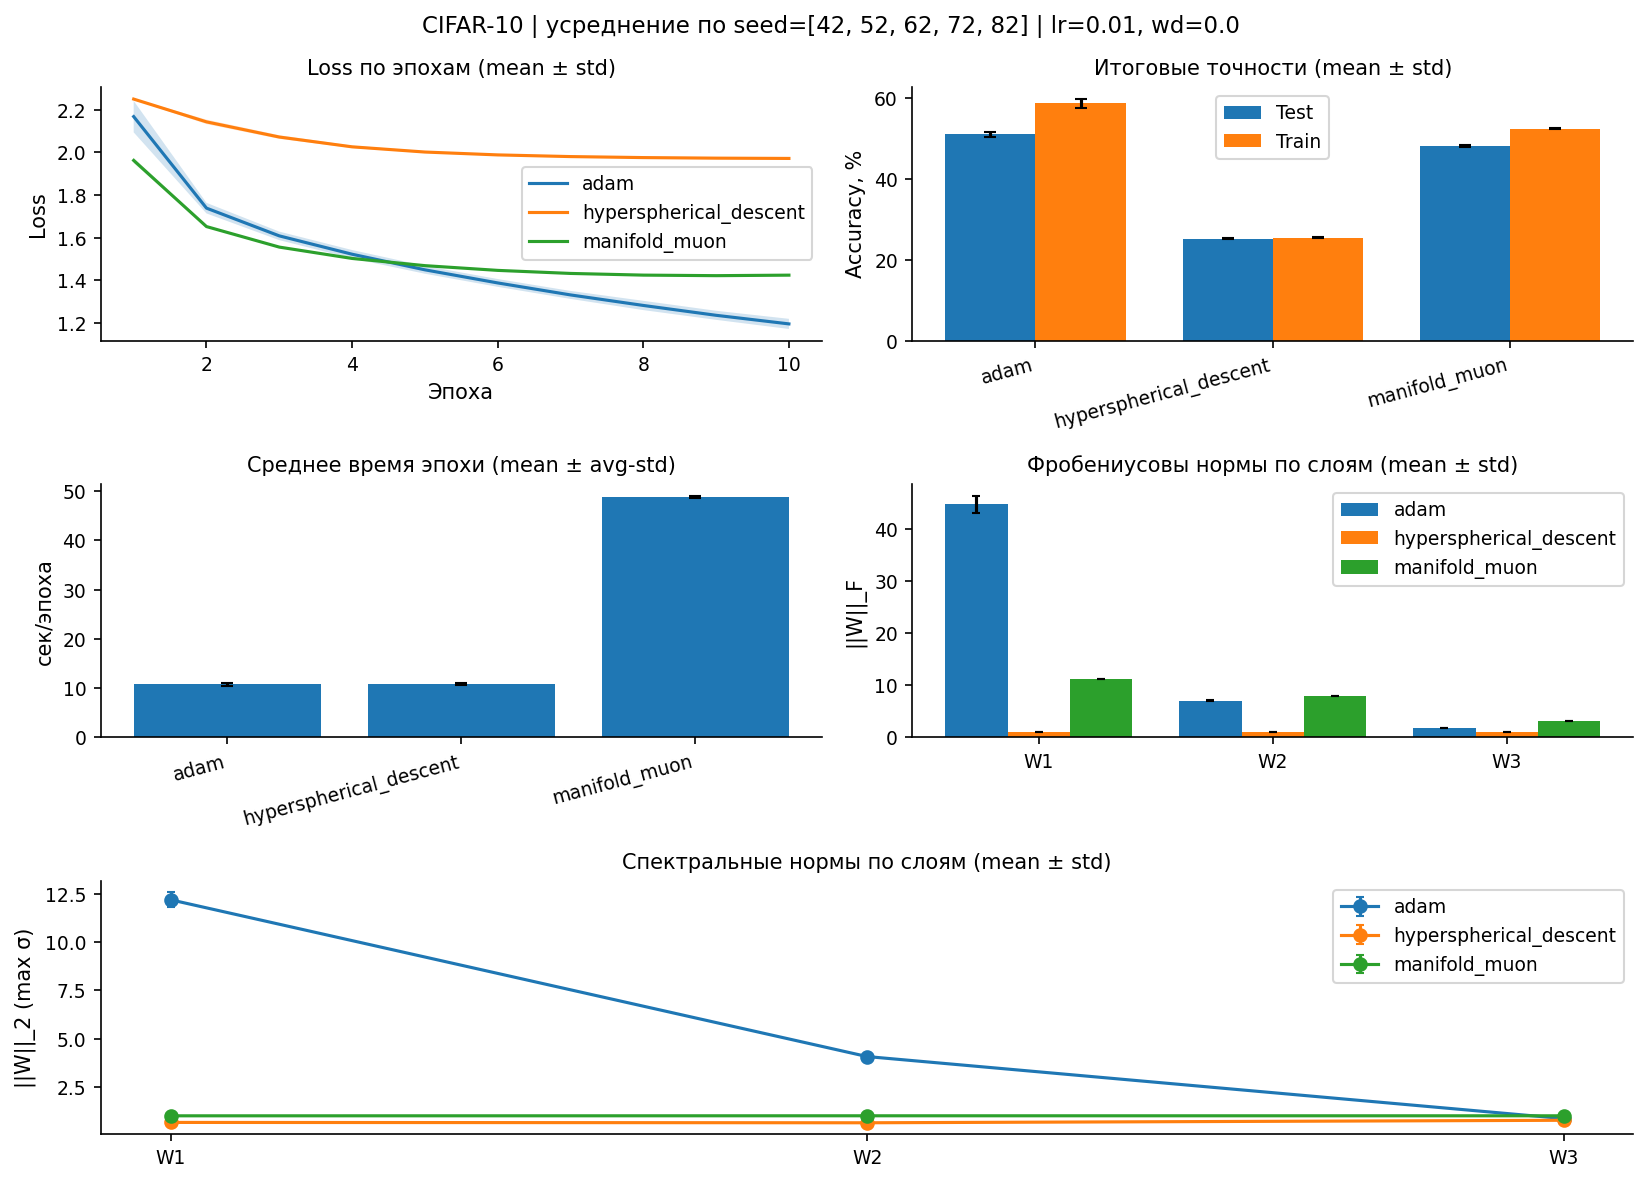

In [ ]:
# ====== НАСТРОЙКИ ======
RESULTS_DIR = "results"
UPDATES = ["adam", "hyperspherical_descent", "manifold_muon"]
SEEDS   = [42, 52, 62, 72, 82]
LR      = "0.01"   # строкой, т.к. имя файла содержит строковое представление
WD      = "0.0"    # в ваших запусках wd не передавали -> 0.0
SAVE_PATH = "figures/summary_avg"   # None -> только показать; иначе сохранит .png/.pdf
# =======================

import os, io, pickle
from typing import Any, Dict, List, Tuple
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

mpl.rcParams["text.usetex"] = False  # без latex
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
})

Results = Dict[str, Any]

# ---------- загрузка (CUDA->CPU safe) ----------
def torch_load_cpu(path: str):
    return torch.load(path, map_location="cpu", weights_only=False)

def pickle_load(path: str):
    with open(path, "rb") as f:
        return pickle.load(f)

def load_results(path: str) -> Results:
    try:
        obj = torch_load_cpu(path)
    except Exception:
        try:
            with open(path, "rb") as f:
                buf = io.BytesIO(f.read())
            obj = torch.load(buf, map_location="cpu", weights_only=False)
        except Exception:
            obj = pickle_load(path)
    if not isinstance(obj, dict):
        raise TypeError(f"{path} не содержит словарь результатов.")
    return obj

def to_cpu_tensor(x) -> torch.Tensor:
    if isinstance(x, torch.Tensor):
        return x.detach().cpu()
    if isinstance(x, (list, tuple)):
        return torch.tensor(x)
    return torch.tensor([x]).squeeze()

def try_load(update: str, seed: int) -> Results:
    fname = f"update-{update}-lr-{LR}-wd-{WD}-seed-{seed}.pkl"
    path = os.path.join(RESULTS_DIR, fname)
    if not os.path.isfile(path):
        raise FileNotFoundError(path)
    return load_results(path)

# ---------- сбор и агрегация ----------
runs_by_update: Dict[str, List[Results]] = {u: [] for u in UPDATES}
missing = []

for u in UPDATES:
    for s in SEEDS:
        try:
            runs_by_update[u].append(try_load(u, s))
        except FileNotFoundError as e:
            missing.append(str(e))

if missing:
    print("⚠️ Не найдено файлов (пропущены при усреднении):")
    for m in missing:
        print("  ", m)

def stack_mean_std(arrs: List[np.ndarray], axis=0):
    if not arrs:
        return None, None
    A = np.stack(arrs, axis=axis)
    return A.mean(axis=axis), A.std(axis=axis, ddof=0)

# подготовка агрегатов
agg = {}
for u, lst in runs_by_update.items():
    if not lst:
        continue

    # epochs — предполагаем одинаковые
    epochs = int(lst[0]["epochs"])
    # потери/время по эпохам
    losses_mean, losses_std = stack_mean_std([np.array(r["epoch_losses"], float) for r in lst], axis=0)
    times_mean,  times_std  = stack_mean_std([np.array(r["epoch_times"],  float) for r in lst], axis=0)

    # итоговые точности
    test_accs = np.array([float(r["test_acc"]) for r in lst], float)
    train_accs= np.array([float(r["train_acc"]) for r in lst], float)
    test_mean,  test_std  = test_accs.mean(),  test_accs.std(ddof=0)
    train_mean, train_std = train_accs.mean(), train_accs.std(ddof=0)

    # нормы по слоям (Фробениус): форма [seeds, layers]
    norms_per_seed = np.stack([
        np.array([float(to_cpu_tensor(n)) for n in r["norms"]], float)
        for r in lst
    ], axis=0)
    norms_mean = norms_per_seed.mean(axis=0)
    norms_std  = norms_per_seed.std(axis=0, ddof=0)

    # спектральные нормы (max σ по слою)
    spectral_per_seed = []
    for r in lst:
        per_layer = []
        for svals in r["singular_values"]:
            t = to_cpu_tensor(svals).float().flatten()
            per_layer.append(float(t.max()) if t.numel() > 0 else np.nan)
        spectral_per_seed.append(per_layer)
    spectral_per_seed = np.array(spectral_per_seed, float)
    spec_mean = np.nanmean(spectral_per_seed, axis=0)
    spec_std  = np.nanstd(spectral_per_seed,  axis=0, ddof=0)

    agg[u] = {
        "epochs": epochs,
        "loss_mean": losses_mean, "loss_std": losses_std,
        "time_mean": times_mean,  "time_std": times_std,
        "test_mean": test_mean,   "test_std": test_std,
        "train_mean": train_mean, "train_std": train_std,
        "norms_mean": norms_mean, "norms_std": norms_std,
        "spec_mean":  spec_mean,  "spec_std":  spec_std,
    }

if not agg:
    raise SystemExit("Нет агрегированных данных. Проверьте пути/имена .pkl файлов.")

# ---------- рисование на одном полотне ----------
labels_updates = list(agg.keys())
epochs_idx = None
n_layers = len(next(iter(agg.values()))["norms_mean"])
layer_idx = np.arange(n_layers)
layer_labels = [f"W{i+1}" for i in range(n_layers)]

fig = plt.figure(figsize=(11, 8))
gs = GridSpec(3, 2, figure=fig)

# (A) Loss: среднее ± std
axA = fig.add_subplot(gs[0, 0])
for u in labels_updates:
    m = agg[u]["loss_mean"]; s = agg[u]["loss_std"]
    if epochs_idx is None: epochs_idx = np.arange(1, len(m)+1)
    axA.plot(epochs_idx, m, label=u)
    axA.fill_between(epochs_idx, m - s, m + s, alpha=0.2)
axA.set_xlabel("Эпоха"); axA.set_ylabel("Loss"); axA.set_title("Loss по эпохам (mean ± std)")
axA.legend(loc="best")

# (B) Итоговые точности: bar с ошибками
axB = fig.add_subplot(gs[0, 1])
x = np.arange(len(labels_updates)); width = 0.38
test_means  = [agg[u]["test_mean"]  for u in labels_updates]
test_stds   = [agg[u]["test_std"]   for u in labels_updates]
train_means = [agg[u]["train_mean"] for u in labels_updates]
train_stds  = [agg[u]["train_std"]  for u in labels_updates]

axB.bar(x - width/2, test_means,  width, yerr=test_stds,  label="Test",  capsize=3)
axB.bar(x + width/2, train_means, width, yerr=train_stds, label="Train", capsize=3)
axB.set_xticks(x, labels_updates, rotation=15, ha="right")
axB.set_ylabel("Accuracy, %"); axB.set_title("Итоговые точности (mean ± std)")
axB.legend(loc="best")

# (C) Среднее время эпохи: bar по среднему времени за эпоху, усреднённое по эпохам и seed’ам
axC = fig.add_subplot(gs[1, 0])
avg_time_means = [float(np.mean(agg[u]["time_mean"])) for u in labels_updates]
# std нормально показать как среднюю std по эпохам (грубая, но информативная)
avg_time_stds  = [float(np.mean(agg[u]["time_std"])) for u in labels_updates]
axC.bar(x, avg_time_means, yerr=avg_time_stds, capsize=3)
axC.set_xticks(x, labels_updates, rotation=15, ha="right")
axC.set_ylabel("сек/эпоха"); axC.set_title("Среднее время эпохи (mean ± avg-std)")

# (D) Нормы весов по слоям: группированные столбцы с ошибками
axD = fig.add_subplot(gs[1, 1])
group_width = 0.8
bar_w = group_width / max(1, len(labels_updates))
for i, u in enumerate(labels_updates):
    offs = layer_idx - group_width/2 + bar_w*(i + 0.5)
    axD.bar(offs, agg[u]["norms_mean"], width=bar_w, yerr=agg[u]["norms_std"], capsize=2, label=u)
axD.set_xticks(layer_idx, layer_labels)
axD.set_ylabel("||W||_F"); axD.set_title("Фробениусовы нормы по слоям (mean ± std)")
axD.legend(loc="best")

# (E) Спектральные нормы по слоям: линии с «усиками» ошибки
axE = fig.add_subplot(gs[2, :])
for u in labels_updates:
    axE.errorbar(layer_idx, agg[u]["spec_mean"], yerr=agg[u]["spec_std"], marker="o", capsize=2, label=u)
axE.set_xticks(layer_idx, layer_labels)
axE.set_ylabel("||W||_2 (max σ)"); axE.set_title("Спектральные нормы по слоям (mean ± std)")
axE.legend(loc="best")

fig.suptitle(f"CIFAR-10 | усреднение по seed={SEEDS} | lr={LR}, wd={WD}", fontsize=11)
fig.tight_layout()

if SAVE_PATH:
    os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
    plt.savefig(SAVE_PATH + ".png", bbox_inches="tight")
    plt.savefig(SAVE_PATH + ".pdf", bbox_inches="tight")
    print("Сохранено:", os.path.abspath(SAVE_PATH + ".png"))
    print("Сохранено:", os.path.abspath(SAVE_PATH + ".pdf"))
else:
    plt.show()


In [ ]:
# ===== НАСТРОЙКИ =====
RESULTS_DIR = "results"
UPDATES = ["adam", "hyperspherical_descent", "manifold_muon"]
SEEDS   = [42, 52, 62, 72, 82]
LR      = "0.01"
WD      = "0.0"
OUTPUT_HTML = "figures/cifar_dashboard_avg.html"
SMOOTH_WINDOW = 1   # 1 = без сглаживания
# =====================

import os, io, pickle
from typing import Any, Dict, List
import numpy as np
import torch

from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio

def torch_load_cpu(path): return torch.load(path, map_location="cpu", weights_only=False)
def pickle_load(path):
    with open(path, "rb") as f: return pickle.load(f)
def load_results(path):
    try:
        return torch_load_cpu(path)
    except Exception:
        try:
            with open(path, "rb") as f:
                buf = io.BytesIO(f.read())
            return torch.load(buf, map_location="cpu", weights_only=False)
        except Exception:
            return pickle_load(path)

def to_cpu_tensor(x):
    if isinstance(x, torch.Tensor): return x.detach().cpu()
    if isinstance(x, (list, tuple)): return torch.tensor(x)
    return torch.tensor([x]).squeeze()

def moving_average(x, w=1):
    x = np.asarray(x, float)
    if w <= 1 or len(x) == 0: return x
    if w > len(x): w = max(1, len(x)//3 or 1)
    c = np.convolve(x, np.ones(w)/w, mode="valid")
    pad = len(x) - len(c)
    left, right = pad//2, pad - pad//2
    return np.concatenate([np.full(left, c[0]), c, np.full(right, c[-1])])

def try_load(update, seed):
    fname = f"update-{update}-lr-{LR}-wd-{WD}-seed-{seed}.pkl"
    path = os.path.join(RESULTS_DIR, fname)
    if not os.path.isfile(path):
        raise FileNotFoundError(path)
    obj = load_results(path)
    if not isinstance(obj, dict): raise TypeError(path)
    return obj

# — сбор по апдейтам/сидам —
runs = {u: [] for u in UPDATES}
missing = []
for u in UPDATES:
    for s in SEEDS:
        try: runs[u].append(try_load(u, s))
        except Exception as e: missing.append(str(e))
if missing:
    print("⚠️ Пропущены файлы:")
    for m in missing: print("  ", m)

def stack_mean_std(list_arrays):
    A = np.stack(list_arrays, axis=0)
    return A.mean(0), A.std(0, ddof=0)

agg = {}
for u, lst in runs.items():
    if not lst: continue
    losses_m, losses_s = stack_mean_std([np.array(r["epoch_losses"], float) for r in lst])
    times_m,  times_s  = stack_mean_std([np.array(r["epoch_times"],  float) for r in lst])
    test = np.array([float(r["test_acc"])  for r in lst])
    train= np.array([float(r["train_acc"]) for r in lst])
    # нормы по слоям
    norms = np.stack([[float(to_cpu_tensor(n)) for n in r["norms"]] for r in lst], 0)
    norms_m, norms_s = norms.mean(0), norms.std(0, ddof=0)
    # спектральные нормы (max σ)
    spec_list = []
    for r in lst:
        per_layer = []
        for svals in r["singular_values"]:
            t = to_cpu_tensor(svals).float().flatten()
            per_layer.append(float(t.max()) if t.numel() else np.nan)
        spec_list.append(per_layer)
    spec = np.array(spec_list, float)
    spec_m, spec_s = np.nanmean(spec, 0), np.nanstd(spec, 0, ddof=0)

    agg[u] = dict(
        losses_m=losses_m, losses_s=losses_s,
        times_m=times_m, times_s=times_s,
        test_m=test.mean(), test_s=test.std(ddof=0),
        train_m=train.mean(), train_s=train.std(ddof=0),
        norms_m=norms_m, norms_s=norms_s,
        spec_m=spec_m, spec_s=spec_s
    )

if not agg: raise SystemExit("Нет данных для дашборда.")

updates = list(agg.keys())
epochs = np.arange(1, len(next(iter(agg.values()))["losses_m"])+1)
n_layers = len(next(iter(agg.values()))["norms_m"])
layer_labels = [f"W{i+1}" for i in range(n_layers)]

fig = make_subplots(
    rows=3, cols=2,
    specs=[[{"type":"scatter"}, {"type":"bar"}],
           [{"type":"bar"},     {"type":"bar"}],
           [{"colspan":2, "type":"scatter"}, None]],
    vertical_spacing=0.12, horizontal_spacing=0.1,
    subplot_titles=("Loss по эпохам (mean±std)", "Итоговые точности (mean±std)",
                    "Среднее время эпохи (mean±avg-std)", "Нормы весов по слоям (mean±std)",
                    "Спектральные нормы по слоям (mean±std)")
)

# (A) Loss mean ± std
for u in updates:
    m = moving_average(agg[u]["losses_m"], SMOOTH_WINDOW)
    s = agg[u]["losses_s"]
    fig.add_trace(go.Scatter(x=epochs, y=m, mode="lines", name=f"Loss — {u}"), row=1, col=1)
    fig.add_trace(go.Scatter(x=np.r_[epochs, epochs[::-1]],
                             y=np.r_[m - s, (m + s)[::-1]],
                             fill='toself', fillcolor='rgba(0,0,0,0.08)',
                             line=dict(width=0), showlegend=False, hoverinfo='skip'),
                  row=1, col=1)
fig.update_xaxes(title_text="Эпоха", row=1, col=1)
fig.update_yaxes(title_text="Loss",  row=1, col=1)

# (B) Accuracy bars
fig.add_trace(go.Bar(x=updates, y=[agg[u]["test_m"] for u in updates],
                     error_y=dict(type="data", array=[agg[u]["test_s"] for u in updates], thickness=1.2),
                     name="Test"), row=1, col=2)
fig.add_trace(go.Bar(x=updates, y=[agg[u]["train_m"] for u in updates],
                     error_y=dict(type="data", array=[agg[u]["train_s"] for u in updates], thickness=1.2),
                     name="Train"), row=1, col=2)
fig.update_yaxes(title_text="Accuracy, %", row=1, col=2)

# (C) Time per epoch
avg_t_m = [float(np.mean(agg[u]["times_m"])) for u in updates]
avg_t_s = [float(np.mean(agg[u]["times_s"])) for u in updates]
fig.add_trace(go.Bar(x=updates, y=avg_t_m,
                     error_y=dict(type="data", array=avg_t_s, thickness=1.2),
                     name="sec/epoch"), row=2, col=1)
fig.update_yaxes(title_text="сек/эпоха", row=2, col=1)

# (D) Fro norms per layer
for u in updates:
    fig.add_trace(go.Bar(x=layer_labels, y=agg[u]["norms_m"],
                         error_y=dict(type="data", array=agg[u]["norms_s"], thickness=1.2),
                         name=u), row=2, col=2)
fig.update_yaxes(title_text="‖W‖_F", row=2, col=2)

# (E) Spectral norms per layer
for u in updates:
    fig.add_trace(go.Scatter(x=layer_labels, y=agg[u]["spec_m"], mode="lines+markers", name=f"spec — {u}",
                             error_y=dict(type="data", array=agg[u]["spec_s"], thickness=1.2)),
                  row=3, col=1)
fig.update_yaxes(title_text="‖W‖₂ (= max σ)", row=3, col=1)

fig.update_layout(
    title=f"CIFAR-10 — усреднение по seed={SEEDS} (lr={LR}, wd={WD})",
    barmode="group", template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.12, xanchor="left", x=0.0),
    margin=dict(t=90, l=40, r=20, b=40),
    hovermode="x unified",
    width=1200, height=900
)

os.makedirs(os.path.dirname(OUTPUT_HTML), exist_ok=True)
pio.write_html(fig, file=OUTPUT_HTML, full_html=True, include_plotlyjs="cdn")
print("Сохранено:", os.path.abspath(OUTPUT_HTML))


Сохранено: /content/manifolds/figures/cifar_dashboard_avg.html


In [ ]:
! python3 ./src/main.py --update manifold_muon --epochs 10 --lr 0.01 --seed 42

Training with: manifold_muon
Epochs: 10 --- LR: 0.01 
Epoch 1, Loss: 1.9655897495697956, Time: 15.2617 seconds
Epoch 2, Loss: 1.654185304836351, Time: 15.6538 seconds
Epoch 3, Loss: 1.559152357432307, Time: 15.3096 seconds
Epoch 4, Loss: 1.506979261125837, Time: 15.2422 seconds
Epoch 5, Loss: 1.4732329164232527, Time: 15.3017 seconds
Epoch 6, Loss: 1.4514651614792493, Time: 15.9903 seconds
Epoch 7, Loss: 1.437397528667839, Time: 15.0423 seconds
Epoch 8, Loss: 1.429319615266761, Time: 15.0849 seconds
Epoch 9, Loss: 1.4268631278252115, Time: 15.3294 seconds
Epoch 10, Loss: 1.429022064014357, Time: 15.6322 seconds
Accuracy of the network on the 10000 test images: 48.2 %
Accuracy of the network on the 50000 train images: 52.126 %
Saving results to results/update-manifold_muon-lr-0.01-wd-0.0-seed-42.pkl
Results saved to results/update-manifold_muon-lr-0.01-wd-0.0-seed-42.pkl
